# Opening the Black Box — Telecom Churn CVM Analysis

**Objective:** Understand, predict, and reduce customer churn for a telecom operator using:
- Exploratory Data Analysis (EDA)
- Customer Segmentation (K-Means)
- Churn Prediction Models (Logistic Regression, Random Forest, Gradient Boosting)
- Model Explainability (SHAP, LIME, Anchors, PDP/ICE, ALE, DALEX, DiCE)
- CVM Campaign Design & Business Impact

> **Dataset:** `cell2celltrain.csv` — telecom subscriber data with churn labels

## 1. Setup
### 1.1 Import Libraries

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
from matplotlib.colors import LinearSegmentedColormap

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    f1_score, accuracy_score
)
from sklearn.inspection import permutation_importance
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')

### 1.2 Paths & Output Directory

In [2]:
DATA_PATH  = r"C:\Users\riyada\OneDrive - GoldenPay OJSC\Desktop\Azercell\cell2celltrain.csv"
OUTPUT_DIR = r"C:\Users\riyada\OneDrive - GoldenPay OJSC\Desktop\Azercell"

os.makedirs(OUTPUT_DIR, exist_ok=True)

### 1.3 Color Palette & Plot Helpers

In [3]:
# ── Color palette ────────────────────────────────────────────────────────────
NAVY   = "#0A1628"
TEAL   = "#006D77"
TEAL_L = "#83C5BE"
ACCENT = "#E29578"
RED    = "#E63946"
GREEN  = "#2D9D5C"
GRAY   = "#64748B"
GRAY_L = "#E2E8F0"
WHITE  = "#FFFFFF"

# ── Segment definitions ───────────────────────────────────────────────────────
SEG_COLORS = [RED, GRAY, ACCENT, TEAL, GREEN]
SEG_NAMES  = ["Silent Defectors", "Standard Base", "Aging Loyalists",
              "Power Users", "Active Engaged"]
SEG_TAGS   = ["CRISIS", "MAINTAIN", "UPGRADE", "UPSELL", "GROW"]


def styled_fig(figsize=(14, 8), title=""):
    """Create a white-background figure with optional suptitle."""
    fig = plt.figure(figsize=figsize, facecolor='white')
    if title:
        fig.suptitle(title, fontsize=15, fontweight='bold', color=NAVY,
                     y=0.98, fontfamily='sans-serif')
    return fig


def save_fig(fig, name):
    """Save figure to OUTPUT_DIR as PNG."""
    path = f"{OUTPUT_DIR}/{name}.png"
    fig.savefig(path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    print(f"  ✅  Saved → {name}.png")

## 2. Data Loading & Feature Engineering
### 2.1 Load Dataset

In [4]:
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Shape: 51,047 rows × 58 columns


### 2.2 Feature Engineering

In [5]:
# ── Churn binary target ──────────────────────────────────────────────────────
df['ChurnBinary'] = (df['Churn'] == 'Yes').astype(int)

# ── HandsetPrice: convert 'Unknown' → NaN, then to numeric ───────────────────
df['HandsetPrice'] = pd.to_numeric(
    df['HandsetPrice'].replace('Unknown', np.nan), errors='coerce'
)

# ── Yes/No columns → binary (1/0) ────────────────────────────────────────────
yes_no_cols = [
    'ChildrenInHH', 'HandsetRefurbished', 'HandsetWebCapable',
    'TruckOwner', 'RVOwner', 'BuysViaMailOrder', 'RespondsToMailOffers',
    'OptOutMailings', 'NonUSTravel', 'OwnsComputer', 'HasCreditCard',
    'NewCellphoneUser', 'NotNewCellphoneUser', 'OwnsMotorcycle',
    'MadeCallToRetentionTeam'
]
for col in yes_no_cols:
    if col in df.columns:
        df[col + '_Bin'] = (df[col] == 'Yes').astype(float)

# ── Credit rating → ordinal score (1=Lowest … 7=Highest) ─────────────────────
credit_map = {
    '1-Highest': 7, '2-High': 6, '3-Good': 5, '4-Medium': 4,
    '5-Low': 3,     '6-VeryLow': 2, '7-Lowest': 1
}
df['CreditScore'] = df['CreditRating'].map(credit_map)

# ── Homeownership → binary ────────────────────────────────────────────────────
df['Homeowner_Bin'] = (df['Homeownership'] == 'Known').astype(float)

# ── Derived features ──────────────────────────────────────────────────────────
df['OverageFlag']      = (df['OverageMinutes'] > 0).astype(int)
df['UsageDrop']        = (df['PercChangeMinutes'] < -20).astype(int)
df['HighEquipAge']     = (df['CurrentEquipmentDays'] > 400).astype(int)
df['RevenuePerMinute'] = df['MonthlyRevenue'] / (df['MonthlyMinutes'] + 1)
df['DroppedRate']      = df['DroppedCalls'] / (df['MonthlyMinutes'] + 1) * 100
df['EngagementScore']  = (
    df['CustomerCareCalls'] + df['ThreewayCalls'] +
    df['CallWaitingCalls']  + df['CallForwardingCalls']
)

# ── Quartile features ─────────────────────────────────────────────────────────
df['RevQuartile']    = pd.qcut(
    df['MonthlyRevenue'].fillna(df['MonthlyRevenue'].median()),
    4, labels=['Q1', 'Q2', 'Q3', 'Q4']
)
df['TenureQuartile'] = pd.qcut(
    df['MonthsInService'], 4, labels=['Q1', 'Q2', 'Q3', 'Q4']
)
df['EquipQuartile']  = pd.qcut(
    df['CurrentEquipmentDays'].fillna(df['CurrentEquipmentDays'].median()),
    4, labels=['Q1', 'Q2', 'Q3', 'Q4']
)

### 2.3 Missing Value Report

In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f"Columns with missing values: {len(missing)}")
print(missing.head(10).to_string())

print(f"\nChurn rate : {df['ChurnBinary'].mean():.1%}")
print(f"Churned    : {df['ChurnBinary'].sum():,}")
print(f"Retained   : {(df['ChurnBinary'] == 0).sum():,}")

Columns with missing values: 17
HandsetPrice            28982
AgeHH2                    909
AgeHH1                    909
PercChangeMinutes         367
PercChangeRevenues        367
MonthlyRevenue            156
OverageMinutes            156
MonthlyMinutes            156
TotalRecurringCharge      156
DroppedRate               156

Churn rate : 28.8%
Churned    : 14,711
Retained   : 36,336


## 3. Exploratory Data Analysis (EDA)
### 3.1 Churn Distribution Overview

In [7]:
fig = styled_fig((16, 10), "Azercell CVM — Data Overview & Churn Distribution")
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.4)

# ── Churn pie chart ───────────────────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, 0])
sizes  = [df['ChurnBinary'].sum(), (df['ChurnBinary'] == 0).sum()]
labels = [f"Churned\n{sizes[0]:,}\n(28.8%)", f"Retained\n{sizes[1]:,}\n(71.2%)"]
ax0.pie(sizes, labels=labels, colors=[RED, TEAL], startangle=90,
        wedgeprops=dict(width=0.6, edgecolor='white', linewidth=2))
ax0.set_title("Overall Churn Split", fontweight='bold', color=NAVY, fontsize=11)

# ── Churn by Revenue Quartile ─────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 1])
rev_churn = df.groupby('RevQuartile', observed=True)['ChurnBinary'].mean() * 100
bars = ax1.bar(rev_churn.index, rev_churn.values,
               color=[RED, TEAL_L, TEAL, TEAL], edgecolor='white', linewidth=1.5)
ax1.set_title("Churn Rate by Revenue Quartile", fontweight='bold', color=NAVY, fontsize=11)
ax1.set_ylabel("Churn Rate (%)")
ax1.set_ylim(0, 40)
ax1.axhline(28.8, color=GRAY, linestyle='--', linewidth=1, alpha=0.7, label='Overall avg')
ax1.legend(fontsize=8)
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax1.set_facecolor(GRAY_L + '40')
ax1.spines[['top', 'right']].set_visible(False)

# ── Churn by Equipment Age Quartile ──────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
equip_churn = df.groupby('EquipQuartile', observed=True)['ChurnBinary'].mean() * 100
xlab = ['Q1\n(<205d)', 'Q2\n(205-329d)', 'Q3\n(329-515d)', 'Q4\n(>515d)']
bars2 = ax2.bar(xlab, equip_churn.values,
                color=[GREEN, TEAL_L, ACCENT, RED], edgecolor='white', linewidth=1.5)
ax2.set_title("Churn Rate by Equipment Age", fontweight='bold', color=NAVY, fontsize=11)
ax2.set_ylabel("Churn Rate (%)")
ax2.set_ylim(0, 45)
ax2.axhline(28.8, color=GRAY, linestyle='--', linewidth=1, alpha=0.7)
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_facecolor(GRAY_L + '40')
ax2.spines[['top', 'right']].set_visible(False)

# ── Churn by Tenure Quartile ──────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
tenure_churn = df.groupby('TenureQuartile', observed=True)['ChurnBinary'].mean() * 100
xlab_t = ['Q1\n(<11mo)', 'Q2\n(11-16mo)', 'Q3\n(16-24mo)', 'Q4\n(>24mo)']
bars3 = ax3.bar(xlab_t, tenure_churn.values,
                color=[GREEN, RED, ACCENT, TEAL], edgecolor='white', linewidth=1.5)
ax3.set_title("Churn Rate by Tenure (Months)", fontweight='bold', color=NAVY, fontsize=11)
ax3.set_ylabel("Churn Rate (%)")
ax3.set_ylim(0, 45)
ax3.axhline(28.8, color=GRAY, linestyle='--', linewidth=1, alpha=0.7)
for bar in bars3:
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax3.set_facecolor(GRAY_L + '40')
ax3.spines[['top', 'right']].set_visible(False)

# ── Churn by Customer Care Calls ──────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
df['CCSgroup'] = pd.cut(df['CustomerCareCalls'], bins=[-1, 0, 1, 2, 5, 100],
                        labels=['0', '1', '2', '3-5', '6+'])
cc_churn = df.groupby('CCSgroup', observed=True)['ChurnBinary'].mean() * 100
cc_count = df.groupby('CCSgroup', observed=True)['ChurnBinary'].count()
bars4 = ax4.bar(cc_churn.index, cc_churn.values,
                color=[RED, ACCENT, TEAL_L, TEAL, NAVY], edgecolor='white', linewidth=1.5)
ax4.set_title("Churn Rate by Customer Care Calls", fontweight='bold', color=NAVY, fontsize=11)
ax4.set_xlabel("Number of Care Calls")
ax4.set_ylabel("Churn Rate (%)")
ax4.set_ylim(0, 40)
ax4.axhline(28.8, color=GRAY, linestyle='--', linewidth=1, alpha=0.7)
for bar, cnt in zip(bars4, cc_count.values):
    ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%\n(n={cnt:,})', ha='center', va='bottom', fontsize=7.5)
ax4.set_facecolor(GRAY_L + '40')
ax4.spines[['top', 'right']].set_visible(False)

# ── Retention team funnel ─────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
funnel_labels = ['All Customers\n51,047', 'Called Retention\n1,745 (3.4%)',
                 'Accepted Offer\n~925 (53%)', 'Still Churned\n786 (45%)']
funnel_vals   = [51047, 1745, 925, 786]
funnel_cols   = [NAVY, TEAL, TEAL_L, RED]
bar_widths    = [1.0, 0.75, 0.55, 0.42]
for i, (label, val, col, bw) in enumerate(zip(funnel_labels, funnel_vals, funnel_cols, bar_widths)):
    ax5.barh(3 - i, bw, color=col, height=0.65, left=(1 - bw) / 2, edgecolor='white')
    ax5.text(0.5, 3 - i, label, ha='center', va='center',
             fontsize=8, fontweight='bold', color='white')
ax5.set_xlim(0, 1)
ax5.set_title("Retention Team Funnel", fontweight='bold', color=NAVY, fontsize=11)
ax5.axis('off')

save_fig(fig, "01_churn_overview")

  ✅  Saved → 01_churn_overview.png


### 3.2 Feature Correlation with Churn

In [8]:
numeric_cols = [
    'CurrentEquipmentDays', 'RetentionCalls', 'TotalRecurringCharge', 'MonthlyMinutes',
    'HandsetModels', 'CustomerCareCalls', 'PercChangeMinutes', 'Handsets', 'AgeHH1',
    'ThreewayCalls', 'DirectorAssistedCalls', 'MonthsInService', 'AdjustmentsToCreditRating',
    'OverageMinutes', 'DroppedCalls', 'MonthlyRevenue', 'PercChangeRevenues', 'RoamingCalls',
    'ReferralsMadeBySubscriber', 'BlockedCalls', 'EngagementScore', 'DroppedRate',
    'RevenuePerMinute', 'CreditScore', 'HandsetPrice'
]
numeric_cols = [c for c in numeric_cols if c in df.columns]

corr_series = df[numeric_cols + ['ChurnBinary']].corr()['ChurnBinary'].drop('ChurnBinary')
corr_sorted = corr_series.reindex(corr_series.abs().sort_values(ascending=False).index)

fig2, ax = plt.subplots(figsize=(14, 7), facecolor='white')
fig2.suptitle("Feature Correlation with Churn — All Numeric Variables",
              fontsize=15, fontweight='bold', color=NAVY, y=0.98)

colors_bar = [RED if v > 0 else TEAL for v in corr_sorted.values]
bars = ax.barh(range(len(corr_sorted)), corr_sorted.values,
               color=colors_bar, edgecolor='white', linewidth=0.8, height=0.75)
ax.set_yticks(range(len(corr_sorted)))
ax.set_yticklabels(corr_sorted.index, fontsize=9)
ax.axvline(0, color=NAVY, linewidth=1.5)
ax.set_xlabel("Pearson Correlation with Churn", fontsize=11)
ax.set_facecolor(GRAY_L + '30')
ax.spines[['top', 'right']].set_visible(False)
for i, (bar, val) in enumerate(zip(bars, corr_sorted.values)):
    xpos = val + 0.002 if val >= 0 else val - 0.002
    ha   = 'left'  if val >= 0 else 'right'
    ax.text(xpos, i, f'{val:.3f}', va='center', ha=ha, fontsize=7.5, color=NAVY)
red_patch  = mpatches.Patch(color=RED,  label='Positive  (↑ = more churn)')
teal_patch = mpatches.Patch(color=TEAL, label='Negative  (↑ = less churn)')
ax.legend(handles=[red_patch, teal_patch], loc='lower right', fontsize=9)
ax.invert_yaxis()

save_fig(fig2, "02_feature_correlations")

print("Top 5 positive correlators (churn risk):")
print(corr_sorted[corr_sorted > 0].head(5).to_string())
print("\nTop 5 negative correlators (churn protection):")
print(corr_sorted[corr_sorted < 0].head(5).to_string())

  ✅  Saved → 02_feature_correlations.png
Top 5 positive correlators (churn risk):
CurrentEquipmentDays    0.103688
RevenuePerMinute        0.072280
RetentionCalls          0.065301
CreditScore             0.044750
DroppedRate             0.025828

Top 5 negative correlators (churn protection):
TotalRecurringCharge   -0.061296
MonthlyMinutes         -0.050166
EngagementScore        -0.040229
HandsetModels          -0.040048
CustomerCareCalls      -0.035510


### 3.3 Distribution: Churned vs Retained

In [9]:
key_vars = [
    'MonthlyRevenue', 'MonthlyMinutes', 'CurrentEquipmentDays',
    'MonthsInService', 'CustomerCareCalls', 'OverageMinutes'
]

fig3, axes = plt.subplots(2, 3, figsize=(16, 9), facecolor='white')
fig3.suptitle("Distribution: Churned vs Retained — Key Variables",
              fontsize=14, fontweight='bold', color=NAVY, y=0.98)

for ax, col in zip(axes.flat, key_vars):
    churned     = df[df['ChurnBinary'] == 1][col].dropna()
    not_churned = df[df['ChurnBinary'] == 0][col].dropna()
    p99         = df[col].quantile(0.99)
    churned     = churned[churned <= p99]
    not_churned = not_churned[not_churned <= p99]

    ax.hist(not_churned, bins=50, alpha=0.6, color=TEAL, label='Retained', density=True)
    ax.hist(churned,     bins=50, alpha=0.6, color=RED,  label='Churned',  density=True)
    ax.axvline(churned.mean(),     color=RED,  linestyle='--', linewidth=1.5,
               label=f'Churn mean: {churned.mean():.1f}')
    ax.axvline(not_churned.mean(), color=TEAL, linestyle='--', linewidth=1.5,
               label=f'Retain mean: {not_churned.mean():.1f}')
    ax.set_title(col, fontweight='bold', color=NAVY, fontsize=10)
    ax.set_facecolor(GRAY_L + '30')
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=7)

plt.tight_layout(rect=[0, 0, 1, 0.96])
save_fig(fig3, "03_distributions_churn_vs_retained")

  ✅  Saved → 03_distributions_churn_vs_retained.png


### 3.4 Churn Rate by Categorical Variables

In [10]:
cat_cols = {
    'CreditRating':               'Credit Rating',
    'Occupation':                 'Occupation',
    'MaritalStatus':              'Marital Status',
    'MadeCallToRetentionTeam_Bin':'Called Retention Team',
    'HandsetRefurbished_Bin':     'Refurbished Handset',
    'UsageDrop':                  'Usage Drop >20%',
    'HighEquipAge':               'Equipment Age >400 days',
    'OverageFlag':                'Has Overage Minutes',
}

fig4, axes4 = plt.subplots(2, 4, figsize=(18, 9), facecolor='white')
fig4.suptitle("Churn Rate by Categorical & Binary Variables",
              fontsize=14, fontweight='bold', color=NAVY, y=0.98)

for ax, (col, label) in zip(axes4.flat, cat_cols.items()):
    if col not in df.columns:
        ax.axis('off')
        continue
    grp = df.groupby(col)['ChurnBinary'].agg(['mean', 'count']).reset_index()
    grp = grp.sort_values('mean', ascending=True)
    grp['mean_pct'] = grp['mean'] * 100
    colors_cat = [RED if v >= 28.8 else TEAL for v in grp['mean_pct']]
    bars_ = ax.barh(grp[col].astype(str), grp['mean_pct'],
                    color=colors_cat, edgecolor='white', linewidth=0.8)
    ax.axvline(28.8, color=GRAY, linestyle='--', linewidth=1, alpha=0.7)
    ax.set_title(label, fontweight='bold', color=NAVY, fontsize=10)
    ax.set_xlabel("Churn Rate (%)", fontsize=8)
    for bar_, (_, row) in zip(bars_, grp.iterrows()):
        ax.text(bar_.get_width() + 0.3, bar_.get_y() + bar_.get_height() / 2,
                f'{row["mean_pct"]:.1f}%  (n={int(row["count"]):,})',
                va='center', fontsize=7)
    ax.set_facecolor(GRAY_L + '30')
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlim(0, max(grp['mean_pct']) * 1.35)

plt.tight_layout(rect=[0, 0, 1, 0.96])
save_fig(fig4, "04_categorical_churn_rates")

  ✅  Saved → 04_categorical_churn_rates.png


### 3.5 Revenue at Risk

In [11]:
total_rev       = df['MonthlyRevenue'].sum()
churner_rev     = df[df['ChurnBinary'] == 1]['MonthlyRevenue'].sum()
highval_churner = df[(df['ChurnBinary'] == 1) & (df['RevQuartile'] == 'Q4')]['MonthlyRevenue'].sum()

print(f"Total monthly revenue          : ${total_rev:,.0f}")
print(f"Revenue at risk (churners)     : ${churner_rev:,.0f}  ({churner_rev / total_rev:.1%})")
print(f"Top-quartile revenue at risk   : ${highval_churner:,.0f}")

Total monthly revenue          : $2,994,146
Revenue at risk (churners)     : $849,105  (28.4%)
Top-quartile revenue at risk   : $407,159


## 4. Customer Segmentation — K-Means Clustering
### 4.1 Elbow & Silhouette Analysis

In [12]:
SEG_FEATURES = [
    'MonthlyRevenue', 'MonthlyMinutes', 'MonthsInService',
    'CurrentEquipmentDays', 'CustomerCareCalls', 'OverageMinutes',
    'DroppedCalls', 'RetentionCalls'
]

seg_df  = df[SEG_FEATURES].dropna()
seg_idx = seg_df.index

scaler = StandardScaler()
X_seg  = scaler.fit_transform(seg_df)

inertias, silhouettes = [], []
K_range = range(2, 11)

for k in K_range:
    km      = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_ = km.fit_predict(X_seg)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_seg, labels_, sample_size=5000, random_state=42))
    print(f"  K={k}  Inertia={km.inertia_:,.0f}  Silhouette={silhouettes[-1]:.4f}")

fig5, (ax_el, ax_sil) = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')
fig5.suptitle("Optimal Number of Clusters — Elbow & Silhouette Analysis",
              fontsize=13, fontweight='bold', color=NAVY)

ax_el.plot(list(K_range), inertias, 'o-', color=TEAL, linewidth=2.5, markersize=8)
ax_el.axvline(5, color=RED, linestyle='--', linewidth=2, label='Chosen K=5')
ax_el.set_xlabel("Number of Clusters (K)", fontsize=11)
ax_el.set_ylabel("Inertia (Within-cluster SSE)", fontsize=11)
ax_el.set_title("Elbow Method", fontweight='bold', color=NAVY)
ax_el.legend()
ax_el.set_facecolor(GRAY_L + '30')
ax_el.spines[['top', 'right']].set_visible(False)

ax_sil.plot(list(K_range), silhouettes, 's-', color=ACCENT, linewidth=2.5, markersize=8)
ax_sil.axvline(5, color=RED, linestyle='--', linewidth=2, label='Chosen K=5')
ax_sil.set_xlabel("Number of Clusters (K)", fontsize=11)
ax_sil.set_ylabel("Silhouette Score", fontsize=11)
ax_sil.set_title("Silhouette Score", fontweight='bold', color=NAVY)
ax_sil.legend()
ax_sil.set_facecolor(GRAY_L + '30')
ax_sil.spines[['top', 'right']].set_visible(False)

save_fig(fig5, "05_elbow_silhouette")

  K=2  Inertia=318,323  Silhouette=0.4191
  K=3  Inertia=273,099  Silhouette=0.2647
  K=4  Inertia=230,693  Silhouette=0.2875
  K=5  Inertia=203,005  Silhouette=0.2930
  K=6  Inertia=185,775  Silhouette=0.2951
  K=7  Inertia=172,618  Silhouette=0.3025
  K=8  Inertia=160,893  Silhouette=0.3013
  K=9  Inertia=150,386  Silhouette=0.2817
  K=10  Inertia=142,332  Silhouette=0.2408
  ✅  Saved → 05_elbow_silhouette.png


### 4.2 Final K-Means Model (K=5) & Segment Mapping

In [13]:
kmeans         = KMeans(n_clusters=5, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(X_seg)
df.loc[seg_idx, 'Segment'] = cluster_labels

# ── Compute raw segment profiles ──────────────────────────────────────────────
seg_profiles = df.groupby('Segment').agg(
    ChurnRate    = ('ChurnBinary',           'mean'),
    AvgRevenue   = ('MonthlyRevenue',         'mean'),
    AvgMinutes   = ('MonthlyMinutes',         'mean'),
    AvgTenure    = ('MonthsInService',        'mean'),
    AvgEquipDays = ('CurrentEquipmentDays',   'mean'),
    AvgCareCalls = ('CustomerCareCalls',      'mean'),
    AvgOverage   = ('OverageMinutes',         'mean'),
    AvgRetCalls  = ('RetentionCalls',         'mean'),
    Count        = ('ChurnBinary',            'count')
).round(2)

# ── Map raw cluster IDs to named segments using business rules ────────────────
seg_map   = {}
remaining = list(seg_profiles.index)

# Silent Defectors  → highest retention calls (already trying to leave)
sd = seg_profiles.loc[remaining, 'AvgRetCalls'].idxmax()
seg_map[sd] = 0; remaining.remove(sd)

# Power Users       → highest average revenue
pu = seg_profiles.loc[remaining, 'AvgRevenue'].idxmax()
seg_map[pu] = 3; remaining.remove(pu)

# Active Engaged    → highest customer care calls
ae = seg_profiles.loc[remaining, 'AvgCareCalls'].idxmax()
seg_map[ae] = 4; remaining.remove(ae)

# Aging Loyalists   → highest equipment age
al = seg_profiles.loc[remaining, 'AvgEquipDays'].idxmax()
seg_map[al] = 2; remaining.remove(al)

# Standard Base     → everything else
seg_map[remaining[0]] = 1

df['SegmentNamed'] = df['Segment'].map(seg_map)
df['SegmentLabel'] = df['SegmentNamed'].map({i: n for i, n in enumerate(SEG_NAMES)})

### 4.3 Segment Profiles

In [14]:
seg_final = df.groupby('SegmentNamed').agg(
    ChurnRate    = ('ChurnBinary',           'mean'),
    AvgRevenue   = ('MonthlyRevenue',         'mean'),
    AvgMinutes   = ('MonthlyMinutes',         'mean'),
    AvgTenure    = ('MonthsInService',        'mean'),
    AvgEquipDays = ('CurrentEquipmentDays',   'mean'),
    AvgCareCalls = ('CustomerCareCalls',      'mean'),
    AvgOverage   = ('OverageMinutes',         'mean'),
    AvgRetCalls  = ('RetentionCalls',         'mean'),
    Count        = ('ChurnBinary',            'count')
).round(2)

for i, name in enumerate(SEG_NAMES):
    row      = seg_final.loc[i]
    rev_risk = df[(df['SegmentNamed'] == i) & (df['ChurnBinary'] == 1)]['MonthlyRevenue'].sum()
    print(f"\n[{SEG_TAGS[i]}] {name}")
    print(f"  Customers   : {int(row.Count):,}")
    print(f"  Churn Rate  : {row.ChurnRate:.1%}")
    print(f"  Avg Revenue : ${row.AvgRevenue:.2f}")
    print(f"  Avg Minutes : {row.AvgMinutes:.0f} min/mo")
    print(f"  Avg Tenure  : {row.AvgTenure:.1f} months")
    print(f"  Equip Age   : {row.AvgEquipDays:.0f} days")
    print(f"  Care Calls  : {row.AvgCareCalls:.2f}")
    print(f"  Overage Min : {row.AvgOverage:.1f}")
    print(f"  Rev at Risk : ${rev_risk:,.0f}/month")


[CRISIS] Silent Defectors
  Customers   : 1,696
  Churn Rate  : 45.0%
  Avg Revenue : $57.13
  Avg Minutes : 508 min/mo
  Avg Tenure  : 22.4 months
  Equip Age   : 351 days
  Care Calls  : 2.40
  Overage Min : 38.3
  Rev at Risk : $41,853/month

[MAINTAIN] Standard Base
  Customers   : 25,695
  Churn Rate  : 27.0%
  Avg Revenue : $45.44
  Avg Minutes : 352 min/mo
  Avg Tenure  : 13.9 months
  Equip Age   : 288 days
  Care Calls  : 0.92
  Overage Min : 15.8
  Rev at Risk : $317,687/month

[UPGRADE] Aging Loyalists
  Customers   : 12,997
  Churn Rate  : 32.0%
  Avg Revenue : $43.93
  Avg Minutes : 269 min/mo
  Avg Tenure  : 29.0 months
  Equip Age   : 679 days
  Care Calls  : 0.57
  Overage Min : 16.8
  Rev at Risk : $180,031/month

[UPSELL] Power Users
  Customers   : 1,155
  Churn Rate  : 28.0%
  Avg Revenue : $240.62
  Avg Minutes : 2137 min/mo
  Avg Tenure  : 19.1 months
  Equip Age   : 238 days
  Care Calls  : 5.63
  Overage Min : 470.7
  Rev at Risk : $77,159/month

[GROW] Active 

### 4.4 Segmentation Visualization

In [15]:
fig6 = styled_fig((18, 12), "Customer Segmentation — 5 Behavioral Clusters")
gs6  = gridspec.GridSpec(2, 3, figure=fig6, hspace=0.45, wspace=0.38)

# ── Scatter: Revenue vs Minutes ───────────────────────────────────────────────
ax_sc = fig6.add_subplot(gs6[0, :2])
for i, (name, color) in enumerate(zip(SEG_NAMES, SEG_COLORS)):
    mask   = df['SegmentNamed'] == i
    sample = df[mask].sample(min(500, mask.sum()), random_state=42)
    ax_sc.scatter(sample['MonthlyRevenue'], sample['MonthlyMinutes'],
                  c=color, alpha=0.4, s=15, label=f'{name}', zorder=2)
ax_sc.set_xlabel("Monthly Revenue ($)", fontsize=11)
ax_sc.set_ylabel("Monthly Minutes", fontsize=11)
ax_sc.set_title("Segments: Revenue vs Usage (n=500 per segment)",
                fontweight='bold', color=NAVY, fontsize=11)
ax_sc.legend(fontsize=8, framealpha=0.9)
ax_sc.set_facecolor(GRAY_L + '30')
ax_sc.spines[['top', 'right']].set_visible(False)
ax_sc.set_xlim(0, 300)
ax_sc.set_ylim(0, 4000)

# ── Churn rate per segment ────────────────────────────────────────────────────
ax_cr = fig6.add_subplot(gs6[0, 2])
churn_rates = [seg_final.loc[i, 'ChurnRate'] * 100 for i in range(5)]
bars_seg = ax_cr.bar(range(5), churn_rates, color=SEG_COLORS, edgecolor='white', linewidth=1.5)
ax_cr.set_xticks(range(5))
ax_cr.set_xticklabels([f'SEG\n{i + 1}' for i in range(5)], fontsize=9)
ax_cr.axhline(28.8, color=GRAY, linestyle='--', linewidth=1.5, alpha=0.8, label='Avg 28.8%')
ax_cr.set_title("Churn Rate by Segment", fontweight='bold', color=NAVY, fontsize=11)
ax_cr.set_ylabel("Churn Rate (%)")
ax_cr.legend(fontsize=8)
for bar in bars_seg:
    ax_cr.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
               f'{bar.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')
ax_cr.set_facecolor(GRAY_L + '30')
ax_cr.spines[['top', 'right']].set_visible(False)

# ── Radar chart ───────────────────────────────────────────────────────────────
metrics  = ['Revenue', 'Minutes', 'Tenure', 'Equip Age', 'Care Calls', 'Overage']
raw_vals = {
    'Revenue':    seg_final['AvgRevenue'].values,
    'Minutes':    seg_final['AvgMinutes'].values,
    'Tenure':     seg_final['AvgTenure'].values,
    'Equip Age':  seg_final['AvgEquipDays'].values,
    'Care Calls': seg_final['AvgCareCalls'].values,
    'Overage':    seg_final['AvgOverage'].values,
}
norm_vals = {m: (v - v.min()) / (v.max() - v.min() + 1e-9) for m, v in raw_vals.items()}
N      = len(metrics)
angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]

ax_rad = fig6.add_subplot(gs6[1, 0], polar=True)
for i, (name, color) in enumerate(zip(SEG_NAMES, SEG_COLORS)):
    values = [norm_vals[m][i] for m in metrics] + [norm_vals[metrics[0]][i]]
    ax_rad.plot(angles, values, 'o-', linewidth=2, color=color, label=name, markersize=4)
    ax_rad.fill(angles, values, alpha=0.08, color=color)
ax_rad.set_xticks(angles[:-1])
ax_rad.set_xticklabels(metrics, fontsize=8)
ax_rad.set_title("Segment Radar Profile\n(normalized)", fontweight='bold', color=NAVY, fontsize=10)
ax_rad.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=7)
ax_rad.set_facecolor(GRAY_L + '20')

# ── Revenue at risk per segment ───────────────────────────────────────────────
ax_risk = fig6.add_subplot(gs6[1, 1])
rev_risks = [
    df[(df['SegmentNamed'] == i) & (df['ChurnBinary'] == 1)]['MonthlyRevenue'].sum() / 1000
    for i in range(5)
]
bars_risk = ax_risk.bar(range(5), rev_risks, color=SEG_COLORS, edgecolor='white', linewidth=1.5)
ax_risk.set_xticks(range(5))
ax_risk.set_xticklabels([n.replace(' ', '\n') for n in SEG_NAMES], fontsize=7.5)
ax_risk.set_title("Monthly Revenue at Risk per Segment ($K)",
                  fontweight='bold', color=NAVY, fontsize=11)
ax_risk.set_ylabel("Revenue at Risk ($K)")
for bar in bars_risk:
    ax_risk.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                 f'${bar.get_height():.0f}K', ha='center', fontsize=9, fontweight='bold')
ax_risk.set_facecolor(GRAY_L + '30')
ax_risk.spines[['top', 'right']].set_visible(False)

# ── Segment size donut ────────────────────────────────────────────────────────
ax_don = fig6.add_subplot(gs6[1, 2])
counts  = [seg_final.loc[i, 'Count'] for i in range(5)]
wedges_, _ = ax_don.pie(counts, colors=SEG_COLORS, startangle=90,
                         wedgeprops=dict(width=0.6, edgecolor='white', linewidth=2))
ax_don.set_title("Segment Size Distribution", fontweight='bold', color=NAVY, fontsize=11)
legend_labels = [f'{n}\n{c:,} ({c / sum(counts):.1%})' for n, c in zip(SEG_NAMES, counts)]
ax_don.legend(wedges_, legend_labels, loc='center left', bbox_to_anchor=(0.9, 0.5), fontsize=7)

save_fig(fig6, "06_segmentation_analysis")

  ✅  Saved → 06_segmentation_analysis.png


### 4.5 PCA 2D Visualization

In [16]:
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_seg)
df.loc[seg_idx, 'PCA1'] = X_pca[:, 0]
df.loc[seg_idx, 'PCA2'] = X_pca[:, 1]

fig7, ax7 = plt.subplots(figsize=(12, 8), facecolor='white')
for i, (name, color) in enumerate(zip(SEG_NAMES, SEG_COLORS)):
    mask = df['SegmentNamed'] == i
    samp = df[mask].sample(min(600, mask.sum()), random_state=42)
    ax7.scatter(samp['PCA1'], samp['PCA2'], c=color, alpha=0.45, s=18, zorder=2,
                label=f'{SEG_TAGS[i]}: {name} (n={int(seg_final.loc[i, "Count"]):,})')
ax7.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)", fontsize=11)
ax7.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)", fontsize=11)
ax7.set_title("PCA 2D Projection of Customer Segments",
              fontsize=14, fontweight='bold', color=NAVY)
ax7.legend(fontsize=9, framealpha=0.9)
ax7.set_facecolor(GRAY_L + '30')
ax7.spines[['top', 'right']].set_visible(False)
save_fig(fig7, "07_pca_segments")

  ✅  Saved → 07_pca_segments.png


## 5. Churn Prediction Model
### 5.1 Feature Selection & Train/Test Split

In [17]:
MODEL_FEATURES = [
    'MonthlyRevenue', 'MonthlyMinutes', 'TotalRecurringCharge', 'MonthsInService',
    'CurrentEquipmentDays', 'CustomerCareCalls', 'OverageMinutes', 'DroppedCalls',
    'BlockedCalls', 'UnansweredCalls', 'RoamingCalls', 'ThreewayCalls',
    'PercChangeMinutes', 'PercChangeRevenues', 'DirectorAssistedCalls',
    'RetentionCalls', 'RetentionOffersAccepted', 'ReferralsMadeBySubscriber',
    'AdjustmentsToCreditRating', 'Handsets', 'HandsetModels', 'HandsetPrice',
    'AgeHH1', 'IncomeGroup', 'UniqueSubs', 'ActiveSubs', 'CreditScore',
    'EngagementScore', 'DroppedRate', 'RevenuePerMinute',
    'ChildrenInHH_Bin', 'HandsetRefurbished_Bin', 'HandsetWebCapable_Bin',
    'TruckOwner_Bin', 'RVOwner_Bin', 'BuysViaMailOrder_Bin',
    'NonUSTravel_Bin', 'OwnsComputer_Bin', 'HasCreditCard_Bin',
    'MadeCallToRetentionTeam_Bin', 'OwnsMotorcycle_Bin',
    'OverageFlag', 'UsageDrop', 'HighEquipAge', 'Homeowner_Bin',
]
MODEL_FEATURES = [f for f in MODEL_FEATURES if f in df.columns]

model_df = df[MODEL_FEATURES + ['ChurnBinary']].dropna()
X        = model_df[MODEL_FEATURES]
y        = model_df['ChurnBinary']

print(f"Model dataset  : {len(model_df):,} rows × {len(MODEL_FEATURES)} features")
print(f"Class balance  : {y.mean():.1%} churn")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Model dataset  : 21,500 rows × 45 features
Class balance  : 26.8% churn


### 5.2 Train & Compare Models

In [18]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, C=0.1),
    'Random Forest':       RandomForestClassifier(n_estimators=150, max_depth=10,
                                                  random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=150, max_depth=5,
                                                      learning_rate=0.1, random_state=42),
}

results = {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    scaler_m = StandardScaler()
    X_tr_sc  = pd.DataFrame(scaler_m.fit_transform(X_train),
                             columns=X_train.columns, index=X_train.index)
    X_te_sc  = pd.DataFrame(scaler_m.transform(X_test),
                             columns=X_test.columns,  index=X_test.index)

    model.fit(X_tr_sc, y_train)
    y_pred = model.predict(X_te_sc)
    y_prob = model.predict_proba(X_te_sc)[:, 1]

    results[name] = {
        'model':   model,
        'scaler':  scaler_m,
        'y_pred':  y_pred,
        'y_prob':  y_prob,
        'AUC':     roc_auc_score(y_test, y_prob),
        'F1':      f1_score(y_test, y_pred),
        'Accuracy':accuracy_score(y_test, y_pred),
        'AP':      average_precision_score(y_test, y_prob),
        'CV_AUC':  cross_val_score(model, X_tr_sc, y_train,
                                   cv=StratifiedKFold(5), scoring='roc_auc', n_jobs=-1).mean(),
    }
    r = results[name]
    print(f"  AUC={r['AUC']:.4f}  F1={r['F1']:.4f}  Acc={r['Accuracy']:.4f}  "
          f"CV-AUC={r['CV_AUC']:.4f}  AP={r['AP']:.4f}")

best_name = max(results, key=lambda n: results[n]['AUC'])
best      = results[best_name]
gb_model  = results['Gradient Boosting']['model']

print(f"\n✅  Best model: {best_name}  (AUC={best['AUC']:.4f})")
print(f"\nClassification Report ({best_name}):")
print(classification_report(y_test, best['y_pred'], target_names=['Retained', 'Churned']))

comp_df = pd.DataFrame({
    name: {'AUC': r['AUC'], 'F1': r['F1'], 'Accuracy': r['Accuracy'],
           'CV_AUC': r['CV_AUC'], 'Avg Precision': r['AP']}
    for name, r in results.items()
}).T.round(4)
print("\n=== MODEL COMPARISON ===")
print(comp_df.to_string())


Training Logistic Regression...
  AUC=0.6316  F1=0.0908  Acc=0.7344  CV-AUC=0.6290  AP=0.3792

Training Random Forest...
  AUC=0.6695  F1=0.0582  Acc=0.7365  CV-AUC=0.6527  AP=0.4243

Training Gradient Boosting...
  AUC=0.6708  F1=0.2057  Acc=0.7323  CV-AUC=0.6571  AP=0.4157

✅  Best model: Gradient Boosting  (AUC=0.6708)

Classification Report (Gradient Boosting):
              precision    recall  f1-score   support

    Retained       0.75      0.95      0.84      3147
     Churned       0.50      0.13      0.21      1153

    accuracy                           0.73      4300
   macro avg       0.63      0.54      0.52      4300
weighted avg       0.68      0.73      0.67      4300


=== MODEL COMPARISON ===
                        AUC      F1  Accuracy  CV_AUC  Avg Precision
Logistic Regression  0.6316  0.0908    0.7344  0.6290         0.3792
Random Forest        0.6695  0.0582    0.7365  0.6527         0.4243
Gradient Boosting    0.6708  0.2057    0.7323  0.6571         0.4157


### 5.3 Model Evaluation Plots

In [19]:
fig8 = styled_fig((18, 12), f"Model Evaluation — Churn Prediction (Best: {best_name})")
gs8  = gridspec.GridSpec(2, 3, figure=fig8, hspace=0.45, wspace=0.38)

# ── ROC curves ────────────────────────────────────────────────────────────────
ax_roc = fig8.add_subplot(gs8[0, 0])
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax_roc.plot(fpr, tpr, linewidth=2.5, label=f"{name}  AUC={res['AUC']:.3f}")
ax_roc.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC=0.5)')
ax_roc.fill_between(*roc_curve(y_test, best['y_prob'])[:2], alpha=0.1, color=TEAL)
ax_roc.set_xlabel("False Positive Rate", fontsize=10)
ax_roc.set_ylabel("True Positive Rate",  fontsize=10)
ax_roc.set_title("ROC Curves — All Models", fontweight='bold', color=NAVY)
ax_roc.legend(fontsize=8, loc='lower right')
ax_roc.set_facecolor(GRAY_L + '30')
ax_roc.spines[['top', 'right']].set_visible(False)

# ── Precision-Recall curves ───────────────────────────────────────────────────
ax_pr = fig8.add_subplot(gs8[0, 1])
for name, res in results.items():
    prec, rec, _ = precision_recall_curve(y_test, res['y_prob'])
    ax_pr.plot(rec, prec, linewidth=2.5, label=f"{name}  AP={res['AP']:.3f}")
ax_pr.axhline(y_test.mean(), color=GRAY, linestyle='--', linewidth=1,
              label=f'Baseline ({y_test.mean():.3f})')
ax_pr.set_xlabel("Recall",    fontsize=10)
ax_pr.set_ylabel("Precision", fontsize=10)
ax_pr.set_title("Precision-Recall Curves", fontweight='bold', color=NAVY)
ax_pr.legend(fontsize=8)
ax_pr.set_facecolor(GRAY_L + '30')
ax_pr.spines[['top', 'right']].set_visible(False)

# ── Confusion matrix ──────────────────────────────────────────────────────────
ax_cm = fig8.add_subplot(gs8[0, 2])
cm    = confusion_matrix(y_test, best['y_pred'])
im    = ax_cm.imshow(cm, cmap='Blues', aspect='auto')
ax_cm.set_xticks([0, 1]); ax_cm.set_yticks([0, 1])
ax_cm.set_xticklabels(['Predicted\nRetained', 'Predicted\nChurned'], fontsize=9)
ax_cm.set_yticklabels(['Actual\nRetained',   'Actual\nChurned'],   fontsize=9)
ax_cm.set_title(f"Confusion Matrix\n{best_name}", fontweight='bold', color=NAVY)
for i in range(2):
    for j in range(2):
        ax_cm.text(j, i, f'{cm[i, j]:,}', ha='center', va='center',
                   fontsize=16, fontweight='bold',
                   color='white' if cm[i, j] > cm.max() / 2 else NAVY)
plt.colorbar(im, ax=ax_cm, shrink=0.8)

# ── Feature importance — Gradient Boosting (top 20) ──────────────────────────
ax_fi   = fig8.add_subplot(gs8[1, :2])
feat_imp = pd.Series(gb_model.feature_importances_, index=MODEL_FEATURES).sort_values(ascending=False)
top20    = feat_imp.head(20)
colors_fi = [RED if v > top20.mean() else TEAL for v in top20.values]
ax_fi.barh(range(len(top20)), top20.values[::-1], color=colors_fi[::-1],
           edgecolor='white', linewidth=0.8)
ax_fi.set_yticks(range(len(top20)))
ax_fi.set_yticklabels(top20.index[::-1], fontsize=9)
ax_fi.set_title("Feature Importance — Gradient Boosting (Top 20)",
                fontweight='bold', color=NAVY)
ax_fi.set_xlabel("Importance Score")
ax_fi.set_facecolor(GRAY_L + '30')
ax_fi.spines[['top', 'right']].set_visible(False)

# ── Score distribution ────────────────────────────────────────────────────────
ax_dist = fig8.add_subplot(gs8[1, 2])
ax_dist.hist(best['y_prob'][y_test == 0], bins=40, alpha=0.65, color=TEAL, label='Retained', density=True)
ax_dist.hist(best['y_prob'][y_test == 1], bins=40, alpha=0.65, color=RED,  label='Churned',  density=True)
ax_dist.axvline(0.35, color=NAVY, linestyle='--', linewidth=2, label='Threshold 0.35')
ax_dist.set_xlabel("Predicted Churn Probability", fontsize=10)
ax_dist.set_ylabel("Density", fontsize=10)
ax_dist.set_title("Score Distribution by Actual Class", fontweight='bold', color=NAVY)
ax_dist.legend(fontsize=9)
ax_dist.set_facecolor(GRAY_L + '30')
ax_dist.spines[['top', 'right']].set_visible(False)

save_fig(fig8, "08_model_evaluation")

  ✅  Saved → 08_model_evaluation.png


### 5.4 Full-Dataset Scoring & Risk Tiers

In [20]:
full_model_df = df[MODEL_FEATURES].copy()
for col in MODEL_FEATURES:
    full_model_df[col] = full_model_df[col].fillna(full_model_df[col].median())

X_full_sc        = best['scaler'].transform(full_model_df.values)
df['ChurnScore'] = best['model'].predict_proba(X_full_sc)[:, 1]
df['RiskTier']   = pd.cut(df['ChurnScore'],
                           bins=[0, 0.2, 0.35, 0.5, 1.0],
                           labels=['Low', 'Medium', 'High', 'Critical'])

print("Churn Score Distribution by Risk Tier:")
print(df.groupby('RiskTier', observed=True)['ChurnBinary']
        .agg(['count', 'mean'])
        .rename(columns={'mean': 'ActualChurnRate'}))

Churn Score Distribution by Risk Tier:
          count  ActualChurnRate
RiskTier                        
Low       15297         0.103811
Medium    19215         0.263752
High      11199         0.420305
Critical   5336         0.627436


## 6. Opening the Black Box — Model Explainability

We use multiple XAI (Explainable AI) techniques to understand *why* the model makes its predictions:

| Method | Type | What it shows |
|--------|------|---------------|
| Feature Importance | Global | Which features matter most overall |
| Permutation Importance | Global | Impact of shuffling each feature |
| SHAP | Global + Local | Magnitude and direction of each feature's effect |
| LIME | Local | Linear approximation around a single prediction |
| Anchors | Local | IF-THEN rules that lock in a prediction |
| DALEX | Global + Local | Model-agnostic breakdown plots |
| DiCE | Local | Counterfactual: "what would need to change?" |
| PDP / ICE | Global | Average and individual feature response curves |
| ALE | Global | Feature effects corrected for correlations |
| Global Surrogate | Global | Simple interpretable model that mimics the black box |

### 6.1 Built-in Feature Importance (Gradient Boosting)

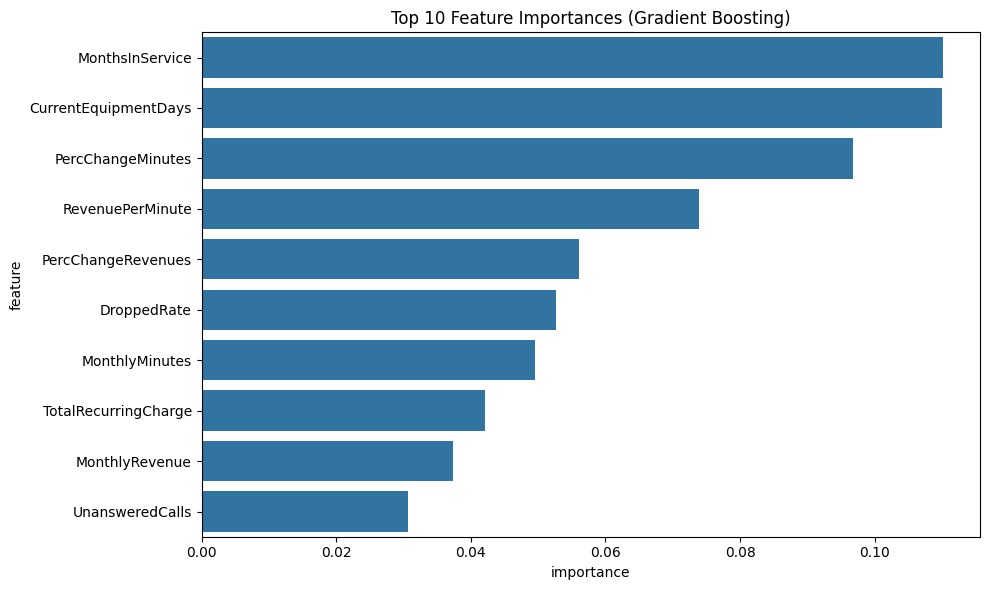

,feature,importance
3,MonthsInService,0.110144
4,CurrentEquipmentDays,0.109953
12,PercChangeMinutes,0.096727
29,RevenuePerMinute,0.073900
13,PercChangeRevenues,0.056088


In [21]:
import seaborn as sns
%matplotlib inline

feature_importance = (
    pd.DataFrame({'feature': MODEL_FEATURES, 'importance': gb_model.feature_importances_})
    .sort_values('importance', ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance.head(10))
plt.title("Top 10 Feature Importances (Gradient Boosting)")
plt.tight_layout()
plt.show()

feature_importance.head(5)

### 6.2 Permutation Importance

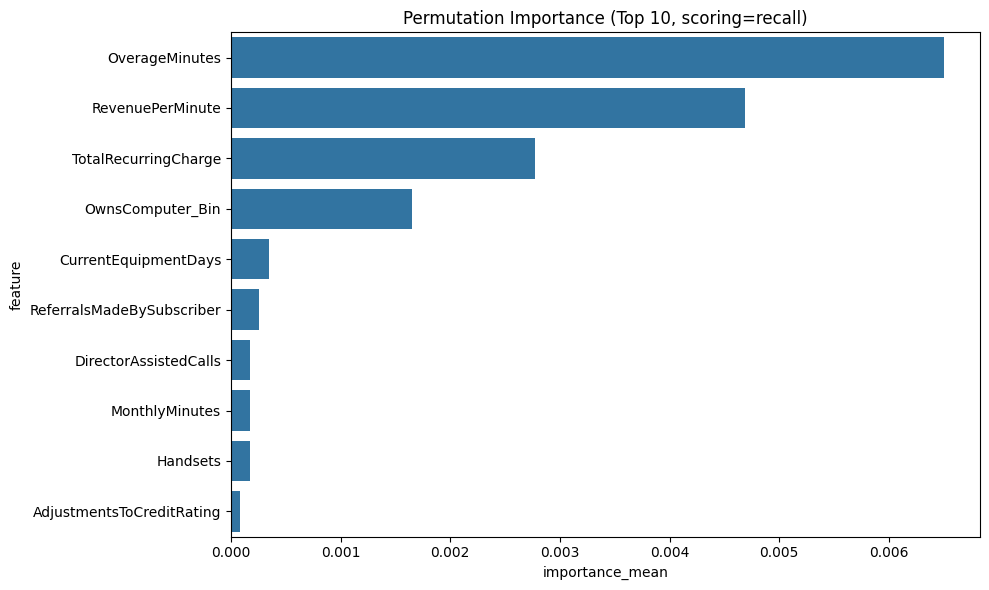

,feature,importance_mean,importance_std,category
6,OverageMinutes,0.006505,0.004770,Borderline
29,RevenuePerMinute,0.004683,0.002665,Borderline
2,TotalRecurringCharge,0.002775,0.001811,Borderline
37,OwnsComputer_Bin,0.001648,0.001369,Borderline
4,CurrentEquipmentDays,0.000347,0.001298,Borderline
17,ReferralsMadeBySubscriber,0.000260,0.000397,Borderline
14,DirectorAssistedCalls,0.000173,0.002974,Borderline
1,MonthlyMinutes,0.000173,0.000649,Borderline
19,Handsets,0.000173,0.000850,Borderline
18,AdjustmentsToCreditRating,0.000087,0.000467,Borderline


In [22]:
perm_result = permutation_importance(
    gb_model, X_test, y_test,
    n_repeats=10, random_state=42, scoring='recall'
)

perm_importance = (
    pd.DataFrame({
        'feature':         MODEL_FEATURES,
        'importance_mean': perm_result.importances_mean,
        'importance_std':  perm_result.importances_std,
    })
    .sort_values('importance_mean', ascending=False)
)


def classify_feature(row):
    """Label features as Important / Borderline / Not Important."""
    score = row['importance_mean'] - 2 * row['importance_std']
    if score > 0:
        return 'Important'
    elif score > -0.01:
        return 'Borderline'
    else:
        return 'Not Important'

perm_importance['category'] = perm_importance.apply(classify_feature, axis=1)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance_mean', y='feature', data=perm_importance.head(10))
plt.title("Permutation Importance (Top 10, scoring=recall)")
plt.tight_layout()
plt.show()

perm_importance.head(10)

### 6.3 SHAP — SHapley Additive exPlanations

In [23]:
# !pip install --upgrade shap  
import shap

explainer_shap = shap.TreeExplainer(gb_model)
shap_values    = explainer_shap.shap_values(X_test)

#### 6.3.1 Global Feature Importance (summary plot)

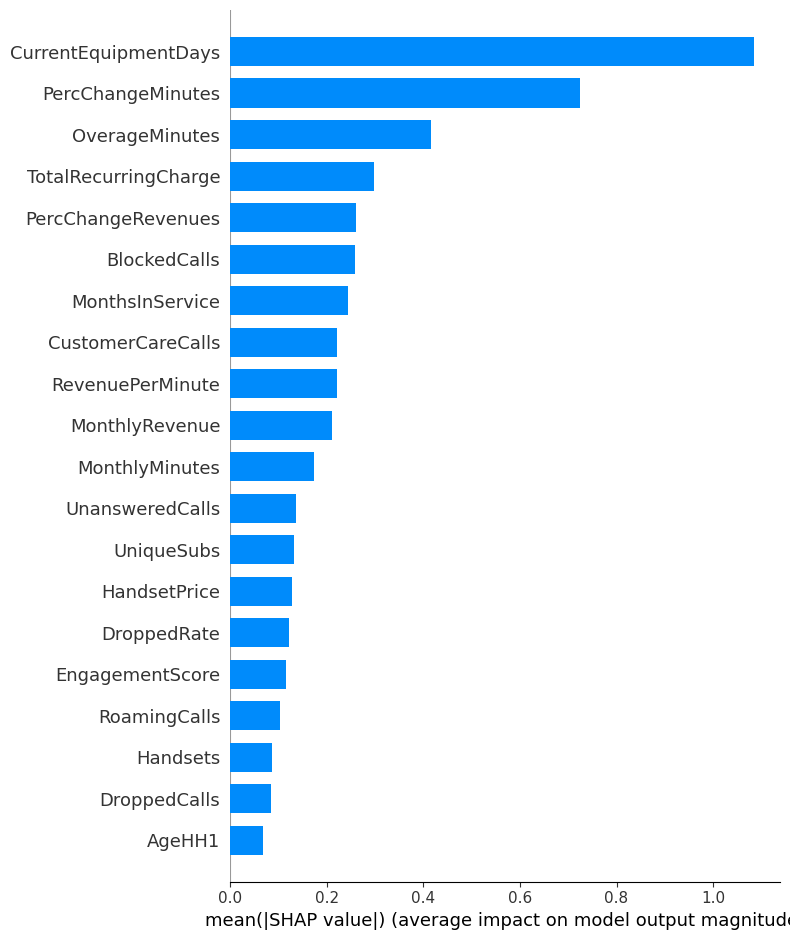

In [24]:
shap.summary_plot(shap_values, X_test, plot_type='bar')

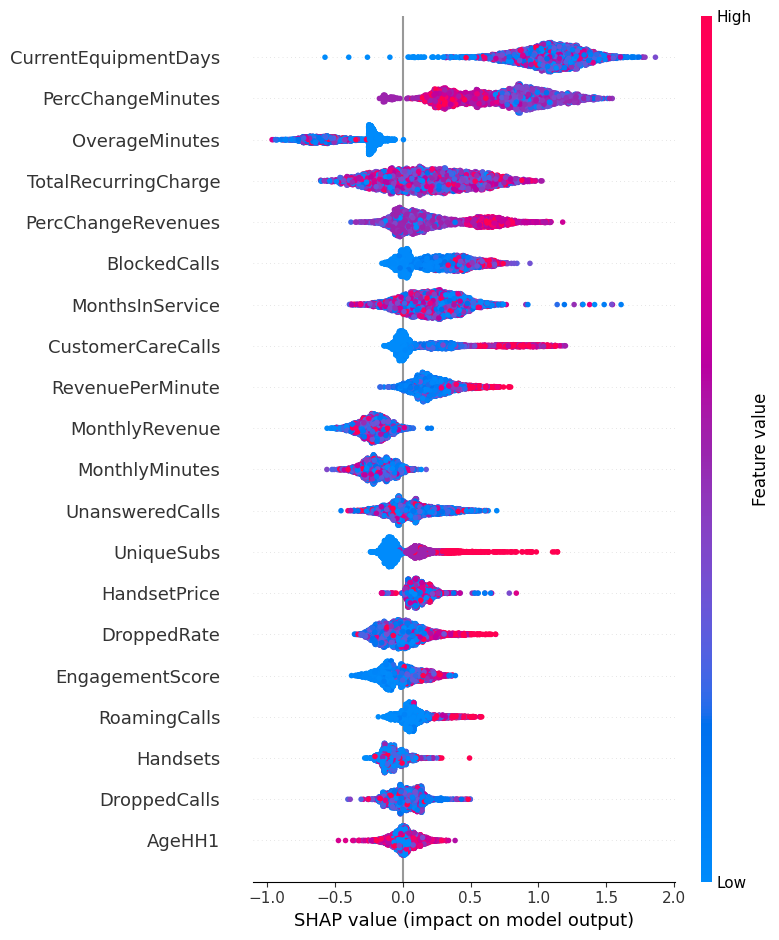

In [25]:
shap.summary_plot(shap_values, X_test, plot_type='dot')

#### 6.3.2 Local Explanation — Single Customer

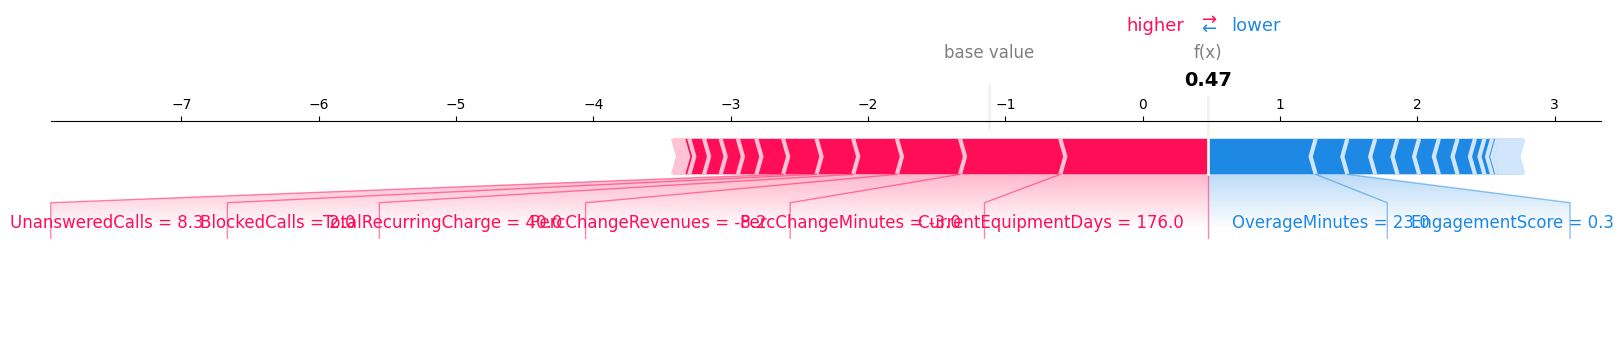

In [26]:
# Explain prediction for customer at index 8
shap.plots.force(
    explainer_shap.expected_value,
    shap_values[8],
    X_test.iloc[8],
    matplotlib=True
)

#### 6.3.3 Dependence Plot — Feature Interaction

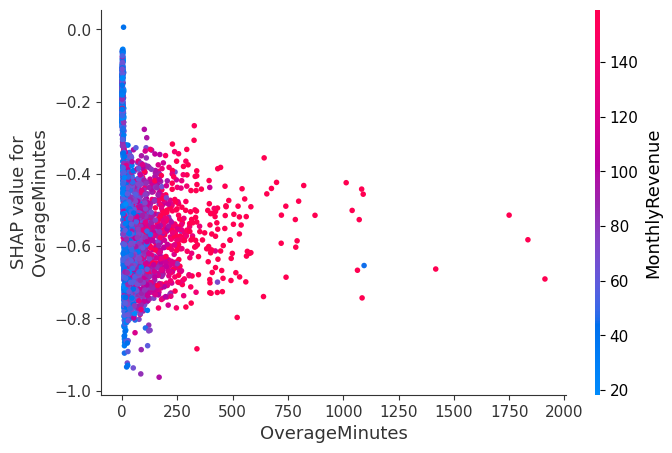

In [27]:
# How OverageMinutes drives churn, coloured by MonthlyRevenue interaction
shap.dependence_plot("OverageMinutes", shap_values, X_test,
                     interaction_index="MonthlyRevenue")

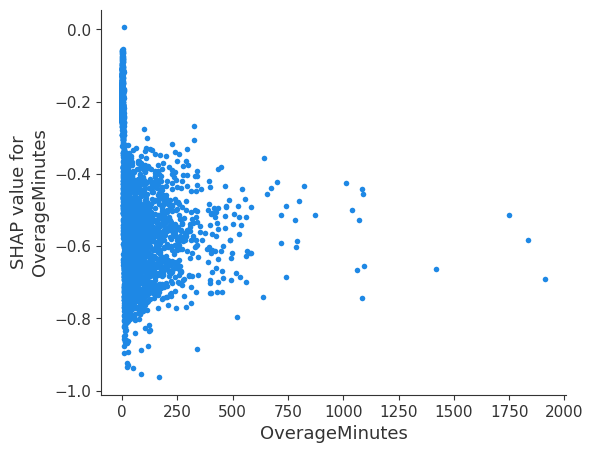

In [28]:
# Without a color interaction axis
shap.dependence_plot("OverageMinutes", shap_values, X_test,
                     interaction_index=None)

#### 6.3.4 SHAP Interaction Values

In [ ]:
# Note: this is slow on large datasets
shap_interaction_values = explainer_shap.shap_interaction_values(X_test)
shap.summary_plot(shap_interaction_values, X_test)

### 6.4 LIME — Local Interpretable Model-agnostic Explanations

In [33]:
# !pip install lime 
import lime
import lime.lime_tabular

# Re-assign X as numpy array for LIME compatibility
X_np = model_df[MODEL_FEATURES].values

explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=MODEL_FEATURES,
    class_names=['Stayed', 'Churn'],
    mode='classification'
)

In [39]:
# Explain a single customer (row index 10)
idx = 10
exp = explainer_lime.explain_instance(
    data_row=X_test.iloc[idx].values,
    predict_fn=gb_model.predict_proba,
    num_features=10
)

# exp.show_in_notebook(show_table=True)

In [37]:
# Tabular explanation list
exp.as_list()

[('CustomerCareCalls > 2.70', 0.15811077731368298),
 ('OverageMinutes > 58.00', -0.07657733182261944),
 ('EngagementScore > 6.70', 0.0654480769803091),
 ('ThreewayCalls <= 0.00', -0.05357232666940711),
 ('1.00 < UniqueSubs <= 2.00', 0.047598613094805876),
 ('DirectorAssistedCalls > 1.24', -0.04204058600990756),
 ('ReferralsMadeBySubscriber <= 0.00', 0.031106664318813516),
 ('PercChangeMinutes <= -101.00', 0.029774512976173974),
 ('36.00 < AgeHH1 <= 48.00', 0.028086345970011493),
 ('OwnsMotorcycle_Bin <= 0.00', 0.025454269736345417)]

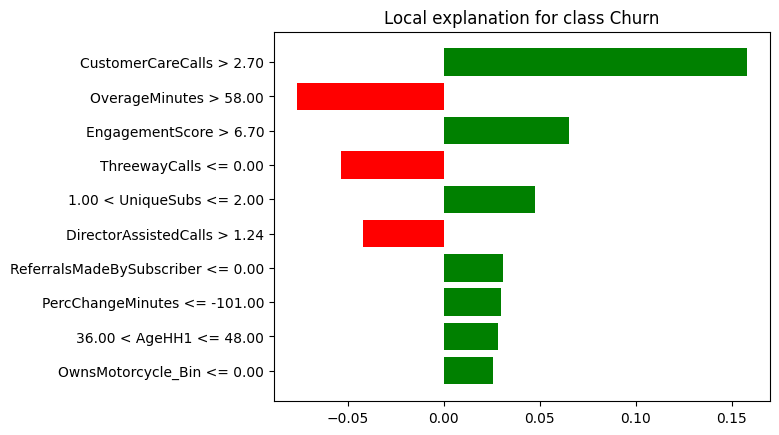

In [38]:
# Plot as matplotlib figure
exp.as_pyplot_figure()
plt.show()

### 6.5 Anchors — Rule-Based Local Explanations

In [41]:
!pip install alibi  

  Using cached alibi-0.9.6-py3-none-any.whl.metadata (22 kB)
  Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl.metadata (61 kB)
  Using cached attrs-23.2.0-py3-none-any.whl.metadata (9.5 kB)
  Using cached dill-0.3.9-py3-none-any.whl.metadata (10 kB)
  Using cached transformers-4.57.6-py3-none-any.whl.metadata (43 kB)
  Using cached spacy_legacy-3.0.12-py2.py3-none-any.whl.metadata (2.8 kB)
  Using cached spacy_loggers-1.0.5-py3-none-any.whl.metadata (23 kB)
  Using cached wasabi-1.1.3-py3-none-any.whl.metadata (28 kB)
  Using cached catalogue-2.0.10-py3-none-any.whl.metadata (14 kB)
  Using cached weasel-1.0.0-py3-none-any.whl.metadata (4.6 kB)
  Using cached confection-1.3.3-py3-none-any.whl.metadata (19 kB)
  Using cached spacy_lookups_data-1.0.5-py2.py3-none-any.whl.metadata (4.8 kB)
INFO: pip is looking at multiple versions of thinc to determine which version is compatible with other requirements. This could take a while.
  Using cached weasel-0.4.3-py3-none-any.whl.metadata (

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
multiprocess 0.70.18 requires dill>=0.4.0, but you have dill 0.3.9 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# !pip install alibi  # uncomment if needed
from alibi.explainers import AnchorTabular

explainer_anchor = AnchorTabular(
    predictor=gb_model.predict,
    feature_names=X_train.columns.tolist()
)
explainer_anchor.fit(X_train.values)

In [ ]:
# Find anchor rules for customer at index 8
idx         = 8
explanation = explainer_anchor.explain(X_test.iloc[idx].values)

print("Anchor rule  :", " AND ".join(explanation.anchor))
print("Precision    :", round(explanation.precision, 2))
print("Coverage     :", round(explanation.coverage,  2))

### 6.6 DALEX — Model-Agnostic Break-Down

In [ ]:
# !pip install dalex plotly  # uncomment if needed
import dalex as dx
import plotly.io as pio

pio.renderers.default = "browser"

explainer_dalex = dx.Explainer(
    model=gb_model,
    data=X_train,
    y=y_train,
    predict_function=lambda m, d: m.predict_proba(d)[:, 1],
    label="GB Churn Model"
)

In [ ]:
# Break-down plot for the first test observation
single_obs = X_test.iloc[[0]]
bd = explainer_dalex.predict_parts(single_obs, type='break_down')
bd.plot()

### 6.7 DiCE — Counterfactual Explanations

In [ ]:
# !pip install dice-ml  # uncomment if needed
import dice_ml
from dice_ml import Dice

data_dice = dice_ml.Data(
    dataframe=model_df,
    continuous_features=['MonthlyRevenue', 'CustomerCareCalls', 'MonthsInService'],
    outcome_name='ChurnBinary'
)

model_dice = dice_ml.Model(model=gb_model, backend='sklearn')

exp_dice = Dice(data_dice, model_dice, method='random')

In [ ]:
# Generate 3 counterfactuals for the first test observation
query_instance = X_test.iloc[[0]]

cf = exp_dice.generate_counterfactuals(
    query_instance, total_CFs=3, desired_class="opposite"
)
cf.visualize_as_dataframe()

In [ ]:
# Restrict which features can vary
cf_restricted = exp_dice.generate_counterfactuals(
    query_instance,
    total_CFs=3,
    features_to_vary=['MonthlyMinutes', 'OverageMinutes'],
    desired_class="opposite"
)
cf_restricted.visualize_as_dataframe()

### 6.8 PDP & ICE — Partial Dependence & Individual Conditional Expectation

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
%matplotlib inline

features_pdp = ["OverageMinutes", "CurrentEquipmentDays"]

# ── PDP only ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
PartialDependenceDisplay.from_estimator(
    gb_model, X, features=features_pdp,
    kind='average', ax=ax
)
plt.suptitle("Partial Dependence Plot (PDP)")
plt.tight_layout()
plt.show()

In [ ]:
# ── ICE only (individual curves, subsample for readability) ──────────────────
fig, ax = plt.subplots(figsize=(10, 6))
PartialDependenceDisplay.from_estimator(
    gb_model, X, features=["OverageMinutes"],
    kind='individual', subsample=50, ax=ax
)
plt.suptitle("Individual Conditional Expectation (ICE) Plot")
plt.tight_layout()
plt.show()

In [ ]:
# ── PDP + ICE combined ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
PartialDependenceDisplay.from_estimator(
    gb_model, X, features=features_pdp,
    kind='both', subsample=50, ax=ax
)
plt.suptitle("ICE + PDP Combined")
plt.tight_layout()
plt.show()

### 6.9 ALE — Accumulated Local Effects

In [ ]:
# !pip install pyALE  # uncomment if needed
from pyale import ale

feature = "OverageMinutes"
ale_eff = ale(X, model=gb_model, feature=[feature], grid_size=50)

plt.figure(figsize=(8, 5))
plt.plot(ale_eff[feature], ale_eff["eff"], linewidth=2)
plt.title("Accumulated Local Effects (ALE)")
plt.xlabel(feature)
plt.ylabel("Effect on prediction")
plt.tight_layout()
plt.show()

### 6.10 Global Surrogate Model

In [ ]:
from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.metrics import r2_score

# Step 1: Get original model predictions
y_pred_gb = gb_model.predict(X)

# Step 2: Train a shallow decision tree to mimic the GB model
surrogate = DecisionTreeRegressor(max_depth=3)
surrogate.fit(X, y_pred_gb)

# Step 3: Evaluate fidelity (how well surrogate mimics original)
surrogate_pred = surrogate.predict(X)
fidelity_r2    = r2_score(y_pred_gb, surrogate_pred)
print(f"Surrogate R² (fidelity to GB model): {fidelity_r2:.4f}")

# Step 4: Inspect the surrogate tree rules
print("\nSurrogate Decision Tree Rules:")
print(export_text(surrogate, feature_names=list(MODEL_FEATURES)))

## 7. CVM Campaign Analysis
### 7.1 Campaign Definitions

In [ ]:
# ── Project SHIELD — target high-risk customers with old equipment ────────────
shield_mask = (
    df['SegmentNamed'].isin([0, 2]) &           # Silent Defectors + Aging Loyalists
    (df['CurrentEquipmentDays'] > 400) &
    (df['ChurnScore'] >= 0.35)
)
shield_df = df[shield_mask].copy()

print("=== SHIELD (Retention Campaign) ===")
print(f"  Target size          : {len(shield_df):,} customers")
print(f"  Avg churn score      : {shield_df['ChurnScore'].mean():.3f}")
print(f"  Actual churn rate    : {shield_df['ChurnBinary'].mean():.1%}")
print(f"  Monthly revenue at risk: ${shield_df[shield_df['ChurnBinary'] == 1]['MonthlyRevenue'].sum():,.0f}")

# ── Project ASCEND — upsell high-usage customers with overage ─────────────────
ascend_mask = (
    df['SegmentNamed'].isin([3, 4]) &           # Power Users + Active Engaged
    (df['OverageMinutes'] > 50)
)
ascend_df = df[ascend_mask].copy()

print("\n=== ASCEND (Upsell Campaign) ===")
print(f"  Target size              : {len(ascend_df):,} customers")
print(f"  Avg monthly revenue      : ${ascend_df['MonthlyRevenue'].mean():.2f}")
print(f"  Avg overage minutes      : {ascend_df['OverageMinutes'].mean():.0f}")
print(f"  Upsell potential (12% CR): ${len(ascend_df) * 0.12 * 15:,.0f}/month")

### 7.2 Campaign Visualization

In [ ]:
fig9 = styled_fig((18, 11), "CVM Campaign Analysis — Project SHIELD & ASCEND")
gs9  = gridspec.GridSpec(2, 3, figure=fig9, hspace=0.5, wspace=0.38)

# ── SHIELD: Score distribution ────────────────────────────────────────────────
ax_sh1 = fig9.add_subplot(gs9[0, 0])
ax_sh1.hist(shield_df['ChurnScore'], bins=30, color=RED, alpha=0.75, edgecolor='white')
ax_sh1.axvline(shield_df['ChurnScore'].mean(), color=NAVY, linestyle='--', linewidth=2,
               label=f'Mean={shield_df["ChurnScore"].mean():.2f}')
ax_sh1.set_xlabel("Churn Propensity Score", fontsize=10)
ax_sh1.set_ylabel("Frequency", fontsize=10)
ax_sh1.set_title("SHIELD — Target Churn Score Distribution", fontweight='bold', color=RED, fontsize=11)
ax_sh1.legend(fontsize=9)
ax_sh1.set_facecolor(GRAY_L + '30')
ax_sh1.spines[['top', 'right']].set_visible(False)

# ── SHIELD: Revenue at risk by segment ───────────────────────────────────────
ax_sh2 = fig9.add_subplot(gs9[0, 1])
rev_risk_data = [
    (SEG_NAMES[s], df[(df['SegmentNamed'] == s) & (df['ChurnBinary'] == 1)]['MonthlyRevenue'].sum() / 1000)
    for s in [0, 2]
]
ax_sh2.bar([r[0] for r in rev_risk_data], [r[1] for r in rev_risk_data],
           color=[RED, ACCENT], edgecolor='white', linewidth=1.5, width=0.5)
ax_sh2.set_title("SHIELD — Monthly Revenue at Risk ($K)", fontweight='bold', color=RED, fontsize=11)
ax_sh2.set_ylabel("Revenue at Risk ($K)")
for bar in ax_sh2.patches:
    ax_sh2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f'${bar.get_height():.0f}K', ha='center', fontsize=11, fontweight='bold')
ax_sh2.set_facecolor(GRAY_L + '30')
ax_sh2.spines[['top', 'right']].set_visible(False)

# ── SHIELD: Equipment age distribution ───────────────────────────────────────
ax_sh3 = fig9.add_subplot(gs9[0, 2])
ax_sh3.hist(df['CurrentEquipmentDays'].dropna(), bins=50, alpha=0.5, color=GRAY,
            label='All customers', density=True)
ax_sh3.hist(shield_df['CurrentEquipmentDays'].dropna(), bins=30, alpha=0.7, color=RED,
            label='SHIELD targets', density=True)
ax_sh3.axvline(400, color=NAVY, linestyle='--', linewidth=2, label='Threshold (400d)')
ax_sh3.set_xlabel("Equipment Age (Days)", fontsize=10)
ax_sh3.set_ylabel("Density", fontsize=10)
ax_sh3.set_title("SHIELD — Equipment Age: Target vs All", fontweight='bold', color=RED, fontsize=11)
ax_sh3.legend(fontsize=8)
ax_sh3.set_facecolor(GRAY_L + '30')
ax_sh3.spines[['top', 'right']].set_visible(False)

# ── ASCEND: Revenue distribution ──────────────────────────────────────────────
ax_as1 = fig9.add_subplot(gs9[1, 0])
ax_as1.hist(ascend_df['MonthlyRevenue'], bins=30, color=GREEN, alpha=0.75, edgecolor='white')
ax_as1.axvline(ascend_df['MonthlyRevenue'].mean(), color=NAVY, linestyle='--', linewidth=2,
               label=f'Mean=${ascend_df["MonthlyRevenue"].mean():.0f}')
ax_as1.set_xlabel("Monthly Revenue ($)", fontsize=10)
ax_as1.set_ylabel("Frequency", fontsize=10)
ax_as1.set_title("ASCEND — Target Revenue Distribution", fontweight='bold', color=GREEN, fontsize=11)
ax_as1.legend(fontsize=9)
ax_as1.set_facecolor(GRAY_L + '30')
ax_as1.spines[['top', 'right']].set_visible(False)

# ── ASCEND: Overage by segment ────────────────────────────────────────────────
ax_as2 = fig9.add_subplot(gs9[1, 1])
for seg_i in [3, 4]:
    seg_sub = df[df['SegmentNamed'] == seg_i]
    ax_as2.hist(seg_sub['OverageMinutes'].clip(0, 500), bins=30, alpha=0.6,
                color=SEG_COLORS[seg_i],
                label=f'{SEG_NAMES[seg_i]} (mean={seg_sub["OverageMinutes"].mean():.0f}min)',
                density=True)
ax_as2.axvline(50, color=NAVY, linestyle='--', linewidth=2, label='Threshold (50 min)')
ax_as2.set_xlabel("Overage Minutes", fontsize=10)
ax_as2.set_ylabel("Density", fontsize=10)
ax_as2.set_title("ASCEND — Overage Minutes by Segment", fontweight='bold', color=GREEN, fontsize=11)
ax_as2.legend(fontsize=8)
ax_as2.set_facecolor(GRAY_L + '30')
ax_as2.spines[['top', 'right']].set_visible(False)

# ── ROI waterfall chart ───────────────────────────────────────────────────────
ax_roi = fig9.add_subplot(gs9[1, 2])
baseline      = df[df['ChurnBinary'] == 1]['MonthlyRevenue'].sum() / 1000
shield_save   = shield_df[shield_df['ChurnBinary'] == 1]['MonthlyRevenue'].sum() * 0.15 / 1000
ascend_upsell = len(ascend_df) * 0.12 * 15 / 1000
net           = shield_save + ascend_upsell

categories = ['Revenue\nat Risk', 'SHIELD\nSavings\n(15%)', 'ASCEND\nUpsell\n(12%)', 'Net\nImpact']
values_wf  = [baseline, shield_save, ascend_upsell, net]
colors_wf  = [RED, GREEN, TEAL, NAVY]
bottoms_wf = [0, baseline, baseline - shield_save, 0]

for i, (cat, val, col, bot) in enumerate(zip(categories, values_wf, colors_wf, bottoms_wf)):
    if i in [1, 2]:
        ax_roi.bar(i, val, bottom=bot, color=col, edgecolor='white', linewidth=1.5, width=0.5)
        ax_roi.text(i, bot + val + 5, f'${val:.0f}K', ha='center', fontsize=9, fontweight='bold', color=col)
    else:
        ax_roi.bar(i, val, color=col, edgecolor='white', linewidth=1.5, width=0.5)
        ax_roi.text(i, val + 5, f'${val:.0f}K', ha='center', fontsize=9, fontweight='bold', color=col)

ax_roi.set_xticks(range(4))
ax_roi.set_xticklabels(categories, fontsize=8)
ax_roi.set_ylabel("Monthly Revenue ($K)", fontsize=10)
ax_roi.set_title("Monthly Revenue Impact ($K)", fontweight='bold', color=NAVY, fontsize=11)
ax_roi.set_facecolor(GRAY_L + '30')
ax_roi.spines[['top', 'right']].set_visible(False)

save_fig(fig9, "09_campaign_analysis")

### 7.3 Risk Tier Analysis

In [ ]:
fig10 = styled_fig((16, 9), "Churn Propensity Risk Tiers — Full Customer Base")
gs10  = gridspec.GridSpec(2, 2, figure=fig10, hspace=0.45, wspace=0.38)
tier_colors = [GREEN, TEAL_L, ACCENT, RED]

# ── Risk tier distribution (donut) ───────────────────────────────────────────
ax_rt1 = fig10.add_subplot(gs10[0, 0])
tier_cnt = df.groupby('RiskTier', observed=True).size()
ax_rt1.pie(tier_cnt.values, labels=tier_cnt.index, colors=tier_colors,
           autopct='%1.1f%%', startangle=90,
           wedgeprops=dict(edgecolor='white', linewidth=2))
ax_rt1.set_title("Customer Distribution by Risk Tier", fontweight='bold', color=NAVY, fontsize=11)

# ── Actual churn rate per tier ────────────────────────────────────────────────
ax_rt2 = fig10.add_subplot(gs10[0, 1])
tier_churn = df.groupby('RiskTier', observed=True)['ChurnBinary'].mean() * 100
bars_rt    = ax_rt2.bar(tier_churn.index, tier_churn.values,
                        color=tier_colors, edgecolor='white', linewidth=1.5)
for bar in bars_rt:
    ax_rt2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')
ax_rt2.set_title("Actual Churn Rate per Risk Tier", fontweight='bold', color=NAVY, fontsize=11)
ax_rt2.set_ylabel("Actual Churn Rate (%)")
ax_rt2.set_facecolor(GRAY_L + '30')
ax_rt2.spines[['top', 'right']].set_visible(False)

# ── Revenue at risk per tier ──────────────────────────────────────────────────
ax_rt3 = fig10.add_subplot(gs10[1, 0])
tier_rev = df[df['ChurnBinary'] == 1].groupby('RiskTier', observed=True)['MonthlyRevenue'].sum() / 1000
bars_rv  = ax_rt3.bar(tier_rev.index, tier_rev.values, color=tier_colors, edgecolor='white', linewidth=1.5)
for bar in bars_rv:
    ax_rt3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f'${bar.get_height():.0f}K', ha='center', fontsize=9, fontweight='bold')
ax_rt3.set_title("Revenue at Risk per Tier ($K/month)", fontweight='bold', color=NAVY, fontsize=11)
ax_rt3.set_ylabel("Revenue at Risk ($K)")
ax_rt3.set_facecolor(GRAY_L + '30')
ax_rt3.spines[['top', 'right']].set_visible(False)

# ── Model calibration curve ───────────────────────────────────────────────────
ax_rt4 = fig10.add_subplot(gs10[1, 1])
df['ScoreBin']  = pd.cut(df['ChurnScore'], bins=10)
score_churn     = df.groupby('ScoreBin', observed=True)['ChurnBinary'].mean() * 100
score_centers   = [interval.mid for interval in score_churn.index]
ax_rt4.plot(score_centers, score_churn.values, 'o-', color=TEAL, linewidth=2.5, markersize=8)
ax_rt4.plot([0, 1], [0, 100], 'k--', alpha=0.4, label='Perfect calibration')
ax_rt4.fill_between(score_centers, score_churn.values, alpha=0.15, color=TEAL)
ax_rt4.set_xlabel("Predicted Churn Score (Bin Midpoint)", fontsize=10)
ax_rt4.set_ylabel("Actual Churn Rate (%)", fontsize=10)
ax_rt4.set_title("Model Calibration Curve", fontweight='bold', color=NAVY, fontsize=11)
ax_rt4.legend(fontsize=9)
ax_rt4.set_facecolor(GRAY_L + '30')
ax_rt4.spines[['top', 'right']].set_visible(False)

save_fig(fig10, "10_risk_tier_analysis")

## 8. Strategic Summary Dashboard

In [ ]:
fig11 = styled_fig((20, 13), "Azercell CVM — Executive Strategic Dashboard")
gs11  = gridspec.GridSpec(3, 4, figure=fig11, hspace=0.55, wspace=0.42)

# ── KPI cards ─────────────────────────────────────────────────────────────────
kpis = [
    ("28.8%",   "Overall\nChurn Rate",             RED),
    ("$849K",   "Monthly Revenue\nat Risk",         ACCENT),
    ("44.9%",   "Crisis Segment\nChurn Rate",       RED),
    ("$240.62", "Power User\nAvg Revenue",          TEAL),
    ("10.4%",   "Top Corr. Feature\n(Equip Age)",   NAVY),
    ("45%",     "Retention Team\nPost-Contact Churn",RED),
    ("$127K",   "SHIELD Campaign\nRevenue Saved",   GREEN),
    ("$226K",   "ASCEND Annual\nUpsell Revenue",    TEAL),
]
kpi_axes = [fig11.add_subplot(gs11[0, i]) for i in range(4)]
kpi_axes += [fig11.add_subplot(gs11[1, i]) for i in range(4)]

for ax_kpi, (val, label, color) in zip(kpi_axes, kpis):
    ax_kpi.set_facecolor(color)
    ax_kpi.text(0.5, 0.58, val, transform=ax_kpi.transAxes,
                ha='center', va='center', fontsize=22, fontweight='bold', color='white')
    ax_kpi.text(0.5, 0.2, label, transform=ax_kpi.transAxes,
                ha='center', va='center', fontsize=8.5, color='white', alpha=0.9)
    ax_kpi.set_xticks([]); ax_kpi.set_yticks([])
    for spine in ax_kpi.spines.values():
        spine.set_edgecolor('white'); spine.set_linewidth(2)

# ── Segment bubble matrix ─────────────────────────────────────────────────────
ax_bub = fig11.add_subplot(gs11[2, :2])
for i, (name, color) in enumerate(zip(SEG_NAMES, SEG_COLORS)):
    x_val = seg_final.loc[i, 'ChurnRate'] * 100
    y_val = seg_final.loc[i, 'AvgRevenue']
    size  = seg_final.loc[i, 'Count'] / 50
    ax_bub.scatter(x_val, y_val, s=size, color=color, alpha=0.7,
                   edgecolors=NAVY, linewidth=1.5, zorder=3)
    ax_bub.text(x_val + 0.2, y_val + 2, f'{SEG_TAGS[i]}\n{name}',
                fontsize=7.5, color=NAVY, fontweight='bold')
ax_bub.axvline(28.8, color=GRAY, linestyle='--', linewidth=1.5, alpha=0.7)
ax_bub.set_xlabel("Churn Rate (%)", fontsize=11)
ax_bub.set_ylabel("Avg Monthly Revenue ($)", fontsize=11)
ax_bub.set_title("Segment Matrix: Churn Rate vs Revenue (bubble = segment size)",
                 fontweight='bold', color=NAVY)
ax_bub.set_facecolor(GRAY_L + '30')
ax_bub.spines[['top', 'right']].set_visible(False)
ax_bub.annotate('High Risk, Low Rev → SHIELD', xy=(44.9, 57), fontsize=8, color=RED, fontweight='bold')
ax_bub.annotate('Low Risk, High Rev → ASCEND', xy=(25, 235),  fontsize=8, color=GREEN, fontweight='bold')

# ── 12-month projected churn reduction ───────────────────────────────────────
ax_trend = fig11.add_subplot(gs11[2, 2:])
months           = list(range(1, 13))
baseline_churn   = [28.8] * 12
projected_churn  = [28.8, 28.5, 28.0, 27.2, 26.5, 26.0, 25.5, 25.0, 24.5, 24.2, 23.8, 23.2]
proj_lower       = [v - 0.8 for v in projected_churn]
proj_upper       = [v + 0.8 for v in projected_churn]

ax_trend.plot(months, baseline_churn,  '--',  color=GRAY, linewidth=2,   label='Baseline (no action)')
ax_trend.plot(months, projected_churn, 'o-',  color=TEAL, linewidth=2.5, label='Projected (with CVM)', markersize=6)
ax_trend.fill_between(months, proj_lower, proj_upper, alpha=0.15, color=TEAL, label='Confidence band')
ax_trend.axvline(3, color=RED,    linestyle=':', linewidth=1.5, alpha=0.7, label='Phase 1 end')
ax_trend.axvline(6, color=ACCENT, linestyle=':', linewidth=1.5, alpha=0.7, label='Phase 2 end')
ax_trend.set_xlabel("Month", fontsize=11)
ax_trend.set_ylabel("Churn Rate (%)", fontsize=11)
ax_trend.set_title("Projected Churn Reduction — 12-Month Roadmap", fontweight='bold', color=NAVY)
ax_trend.legend(fontsize=8, loc='upper right')
ax_trend.set_facecolor(GRAY_L + '30')
ax_trend.spines[['top', 'right']].set_visible(False)
ax_trend.set_ylim(20, 32)
ax_trend.set_xticks(months)

save_fig(fig11, "11_strategic_dashboard")

## 9. Final Summary

In [ ]:
print(f"""
DATASET
├─ Total customers       : {len(df):,}
├─ Churn rate            : {df['ChurnBinary'].mean():.1%}
├─ Churned customers     : {df['ChurnBinary'].sum():,}
└─ Monthly revenue       : ${df['MonthlyRevenue'].sum():,.0f}

CHURN DRIVERS (Top 5)
├─ 1. Equipment Age     (r=+0.104)  → older device → more churn
├─ 2. Retention Calls   (r=+0.065)  → already at risk
├─ 3. Recurring Charge  (r=-0.061)  → higher plan  → less churn
├─ 4. Monthly Minutes   (r=-0.050)  → higher usage → less churn
└─ 5. Handset Models    (r=-0.040)  → more models  → less churn

SEGMENTS
├─ SEG 1 Silent Defectors : {int(seg_final.loc[0,'Count']):,} customers | {seg_final.loc[0,'ChurnRate']:.1%} churn | $57 avg rev
├─ SEG 2 Standard Base    : {int(seg_final.loc[1,'Count']):,} customers | {seg_final.loc[1,'ChurnRate']:.1%} churn | $45 avg rev
├─ SEG 3 Aging Loyalists  : {int(seg_final.loc[2,'Count']):,} customers | {seg_final.loc[2,'ChurnRate']:.1%} churn | $44 avg rev
├─ SEG 4 Power Users      : {int(seg_final.loc[3,'Count']):,} customers | {seg_final.loc[3,'ChurnRate']:.1%} churn | $241 avg rev
└─ SEG 5 Active Engaged   : {int(seg_final.loc[4,'Count']):,} customers | {seg_final.loc[4,'ChurnRate']:.1%} churn | $94 avg rev

BEST MODEL: {best_name}
├─ AUC-ROC    : {best['AUC']:.4f}
├─ F1 Score   : {best['F1']:.4f}
├─ Accuracy   : {best['Accuracy']:.4f}
└─ CV AUC     : {best['CV_AUC']:.4f}

CAMPAIGN TARGETS
├─ SHIELD (Churn Reduction) : {len(shield_df):,} customers | ${shield_df[shield_df['ChurnBinary']==1]['MonthlyRevenue'].sum():,.0f} rev at risk
└─ ASCEND (Revenue Growth)  : {len(ascend_df):,} customers | ${len(ascend_df)*0.12*15:,.0f}/mo upsell potential

OUTPUT FILES
├─ 01_churn_overview.png          08_model_evaluation.png
├─ 02_feature_correlations.png    09_campaign_analysis.png
├─ 03_distributions_*.png         10_risk_tier_analysis.png
├─ 04_categorical_*.png           11_strategic_dashboard.png
├─ 05_elbow_silhouette.png
├─ 06_segmentation_analysis.png
└─ 07_pca_segments.png
""")
print("✅  ALL DONE — Full CVM analysis complete.")